In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

C:\Users\ilyam\OneDrive\Desktop\mlflow-example\.venv\Lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import warnings
warnings.filterwarnings("ignore", message="Unable to import Axes3D")

In [3]:
transform = transforms.ToTensor()

train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)

test_ds = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform,
)

len(train_ds), len(test_ds)

(60000, 10000)

In [4]:
image, label = train_ds[0]
image.shape, label

(torch.Size([1, 28, 28]), 9)

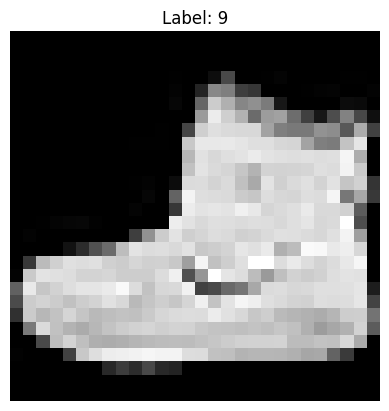

In [5]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

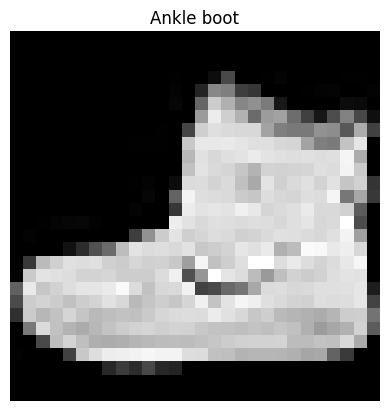

In [7]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(label_names[label])
plt.axis("off")
plt.show()

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Unable to import Axes3D")

import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()

train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)

test_ds = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform,
)

len(train_ds), len(test_ds)

(60000, 10000)

In [3]:
label_names = [
    "T-shirt/top",
    "Trouser"
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

In [4]:
image, label = train_ds[0]
image.shape, label_names[label]

IndexError: list index out of range

In [5]:
len(label_names), label

(9, 9)

In [6]:
label_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

In [7]:
len(label_names), label

(10, 9)

In [8]:
image, label = train_ds[0]
image.shape, label_names[label]

(torch.Size([1, 28, 28]), 'Ankle boot')

In [9]:
image, label = train_ds[0]
image.shape, label_names[label]

(torch.Size([1, 28, 28]), 'Ankle boot')

In [10]:
image, label = train_ds[0]
label

9

In [11]:
image, label = train_ds[0]
image.shape, label_names[label]

(torch.Size([1, 28, 28]), 'Ankle boot')

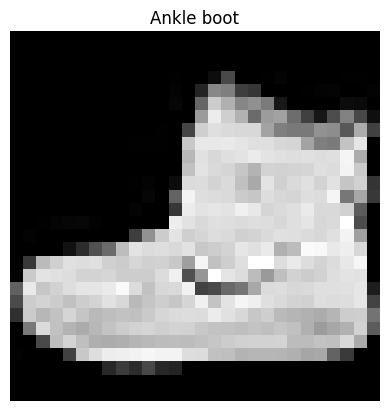

In [12]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(label_names[label])
plt.axis("off")
plt.show()

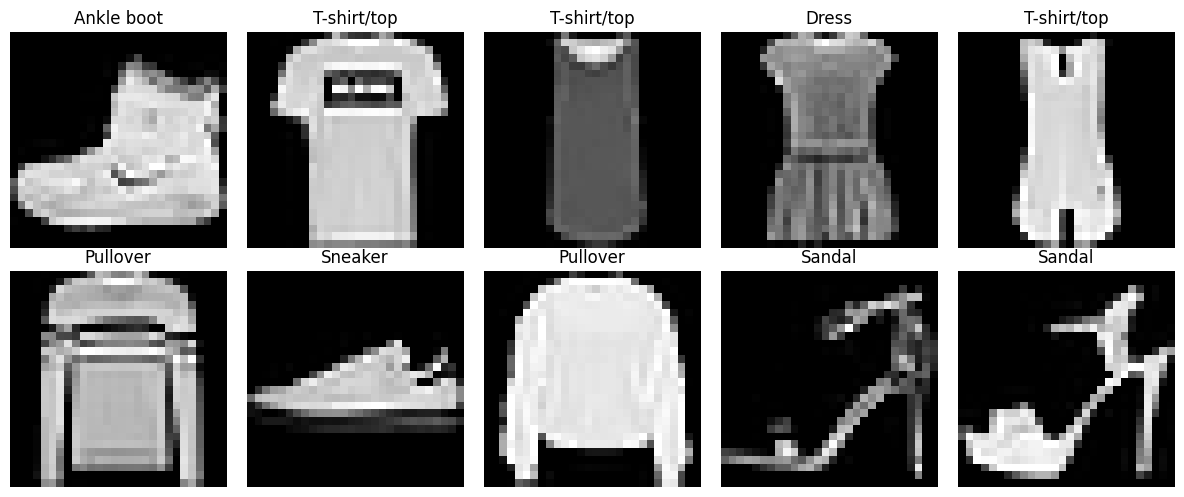

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_ds[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(label_names[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

len(train_loader), len(test_loader)

(938, 157)

In [15]:
images, labels = next(iter(train_loader))
images.shape, labels.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

In [16]:
from torch import nn

class FashionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

In [17]:
model = FashionNet()
model

FashionNet(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [18]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [19]:
images, labels = next(iter(train_loader))
logits = model(images)

logits.shape

torch.Size([64, 10])

In [20]:
loss = loss_fn(logits, labels)
loss

tensor(2.3232, grad_fn=<NllLossBackward0>)

In [21]:
model.train()

total_loss = 0.0
total_examples = 0

for images, labels in train_loader:
    optimizer.zero_grad()

    logits = model(images)
    loss = loss_fn(logits, labels)

    loss.backward()
    optimizer.step()

    total_loss += loss.item() * images.size(0)
    total_examples += images.size(0)

train_loss = total_loss / total_examples
train_loss

0.5235216128031412

In [22]:
model.eval()

total_correct = 0
total_examples = 0
total_test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images)
        loss = loss_fn(logits, labels)

        total_test_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_examples += images.size(0)

test_loss = total_test_loss / total_examples
test_accuracy = total_correct / total_examples

test_loss, test_accuracy

(0.42426518270969393, 0.8464)

In [23]:
model = FashionNet()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = []

for epoch in range(1, 6):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_examples += images.size(0)

    train_loss = total_loss / total_examples

    model.eval()
    total_correct = 0
    total_examples = 0
    total_test_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            logits = model(images)
            loss = loss_fn(logits, labels)

            total_test_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_examples += images.size(0)

    test_loss = total_test_loss / total_examples
    test_accuracy = total_correct / total_examples

    history.append((epoch, train_loss, test_loss, test_accuracy))
    print(f"epoch={epoch} train_loss={train_loss:.4f} test_loss={test_loss:.4f} test_accuracy={test_accuracy:.4f}")

epoch=1 train_loss=0.5231 test_loss=0.4247 test_accuracy=0.8480
epoch=2 train_loss=0.3708 test_loss=0.3770 test_accuracy=0.8634
epoch=3 train_loss=0.3263 test_loss=0.3641 test_accuracy=0.8709
epoch=4 train_loss=0.3051 test_loss=0.3636 test_accuracy=0.8688
epoch=5 train_loss=0.2849 test_loss=0.3613 test_accuracy=0.8696


In [24]:
import pandas as pd

history_df = pd.DataFrame(history, columns=["epoch", "train_loss", "test_loss", "test_accuracy"])
history_df

,epoch,train_loss,test_loss,test_accuracy
0,1,0.523118,0.424676,0.8480
1,2,0.370839,0.376998,0.8634
2,3,0.326293,0.364098,0.8709
3,4,0.305123,0.363622,0.8688
4,5,0.284934,0.361284,0.8696


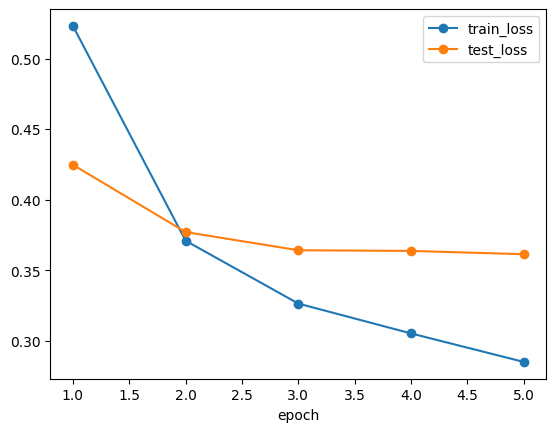

In [25]:
history_df.plot(x="epoch", y=["train_loss", "test_loss"], marker="o")
plt.show()

In [26]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("fashion-mnist-notebook")

2026/03/11 00:45:11 INFO mlflow.tracking.fluent: Experiment with name 'fashion-mnist-notebook' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:C:/Users/ilyam/OneDrive/Desktop/mlflow-example/mlruns/3', creation_time=1773204311163, experiment_id='3', last_update_time=1773204311163, lifecycle_stage='active', name='fashion-mnist-notebook', tags={}, workspace='default'>

In [27]:
with mlflow.start_run(run_name="fashion_net_5_epochs"):
    mlflow.log_param("model_type", "FashionNet")
    mlflow.log_param("epochs", 5)
    mlflow.log_param("batch_size", 64)
    mlflow.log_param("learning_rate", 1e-3)
    mlflow.log_param("optimizer", "Adam")

    mlflow.log_metric("final_train_loss", history_df["train_loss"].iloc[-1])
    mlflow.log_metric("final_test_loss", history_df["test_loss"].iloc[-1])
    mlflow.log_metric("final_test_accuracy", history_df["test_accuracy"].iloc[-1])

    best_idx = history_df["test_accuracy"].idxmax()
    mlflow.log_metric("best_test_accuracy", history_df.loc[best_idx, "test_accuracy"])
    mlflow.log_metric("best_epoch", int(history_df.loc[best_idx, "epoch"]))

In [28]:
with mlflow.start_run(run_name="fashion_net_5_epochs_detailed"):
    mlflow.log_param("model_type", "FashionNet")
    mlflow.log_param("epochs", 5)
    mlflow.log_param("batch_size", 64)
    mlflow.log_param("learning_rate", 1e-3)
    mlflow.log_param("optimizer", "Adam")

    for _, row in history_df.iterrows():
        step = int(row["epoch"])
        mlflow.log_metric("train_loss", row["train_loss"], step=step)
        mlflow.log_metric("test_loss", row["test_loss"], step=step)
        mlflow.log_metric("test_accuracy", row["test_accuracy"], step=step)

In [29]:
import mlflow.pytorch

with mlflow.start_run(run_name="fashion_net_5_epochs_with_model"):
    mlflow.log_param("model_type", "FashionNet")
    mlflow.log_param("epochs", 5)
    mlflow.log_param("batch_size", 64)
    mlflow.log_param("learning_rate", 1e-3)
    mlflow.log_param("optimizer", "Adam")

    for _, row in history_df.iterrows():
        step = int(row["epoch"])
        mlflow.log_metric("train_loss", row["train_loss"], step=step)
        mlflow.log_metric("test_loss", row["test_loss"], step=step)
        mlflow.log_metric("test_accuracy", row["test_accuracy"], step=step)

    mlflow.pytorch.log_model(model, name="model")

2026/03/11 00:45:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


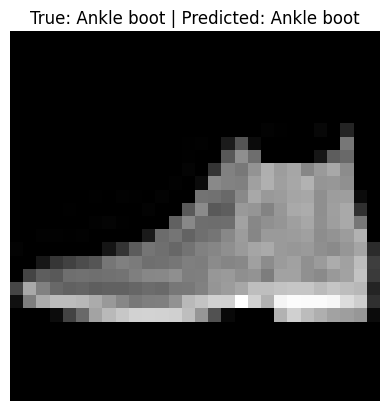

In [30]:
model.eval()

image, true_label = test_ds[0]

with torch.no_grad():
    logits = model(image.unsqueeze(0))
    pred_label = logits.argmax(dim=1).item()

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"True: {label_names[true_label]} | Predicted: {label_names[pred_label]}")
plt.axis("off")
plt.show()

In [31]:
probs = torch.softmax(logits, dim=1).squeeze()

for i, p in enumerate(probs):
    print(f"{label_names[i]}: {p.item():.3f}")

T-shirt/top: 0.000
Trouser: 0.000
Pullover: 0.000
Dress: 0.000
Coat: 0.000
Sandal: 0.001
Shirt: 0.000
Sneaker: 0.009
Bag: 0.000
Ankle boot: 0.990


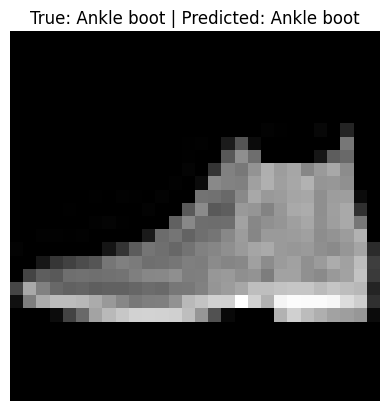

In [32]:
model.eval()

image, true_label = test_ds[0]

with torch.no_grad():
    logits = model(image.unsqueeze(0))
    pred_label = logits.argmax(dim=1).item()

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"True: {label_names[true_label]} | Predicted: {label_names[pred_label]}")
plt.axis("off")
plt.show()

In [33]:
probs = torch.softmax(logits, dim=1).squeeze()

for i, p in enumerate(probs):
    print(f"{label_names[i]}: {p.item():.3f}")

T-shirt/top: 0.000
Trouser: 0.000
Pullover: 0.000
Dress: 0.000
Coat: 0.000
Sandal: 0.001
Shirt: 0.000
Sneaker: 0.009
Bag: 0.000
Ankle boot: 0.990


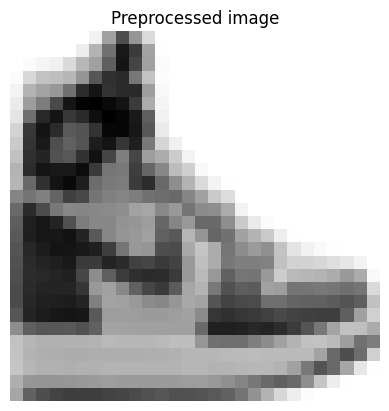

In [34]:
from PIL import Image
from torchvision import transforms

image_path = "Test_External_Sneaker.jpg"

inference_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

external_image = Image.open(image_path)
input_tensor = inference_transform(external_image)

plt.imshow(input_tensor.squeeze(), cmap="gray")
plt.title("Preprocessed image")
plt.axis("off")
plt.show()

In [35]:
model.eval()

with torch.no_grad():
    logits = model(input_tensor.unsqueeze(0))
    pred_label = logits.argmax(dim=1).item()
    probs = torch.softmax(logits, dim=1).squeeze()

print("Predicted class:", label_names[pred_label])

Predicted class: Bag


In [36]:
for i, p in enumerate(probs):
    print(f"{label_names[i]}: {p.item():.3f}")

T-shirt/top: 0.000
Trouser: 0.000
Pullover: 0.000
Dress: 0.000
Coat: 0.000
Sandal: 0.000
Shirt: 0.000
Sneaker: 0.000
Bag: 1.000
Ankle boot: 0.000


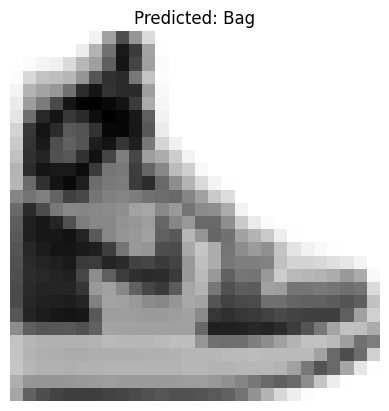

In [37]:
plt.imshow(input_tensor.squeeze(), cmap="gray")
plt.title(f"Predicted: {label_names[pred_label]}")
plt.axis("off")
plt.show()

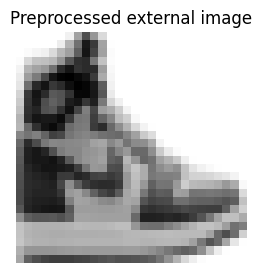

In [38]:
plt.figure(figsize=(3, 3))
plt.imshow(input_tensor.squeeze(), cmap="gray")
plt.title("Preprocessed external image")
plt.axis("off")
plt.show()

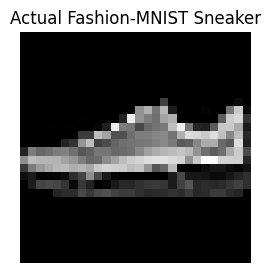

In [39]:
for i in range(len(test_ds)):
    image, label = test_ds[i]
    if label_names[label] == "Sneaker":
        plt.figure(figsize=(3, 3))
        plt.imshow(image.squeeze(), cmap="gray")
        plt.title("Actual Fashion-MNIST Sneaker")
        plt.axis("off")
        plt.show()
        break

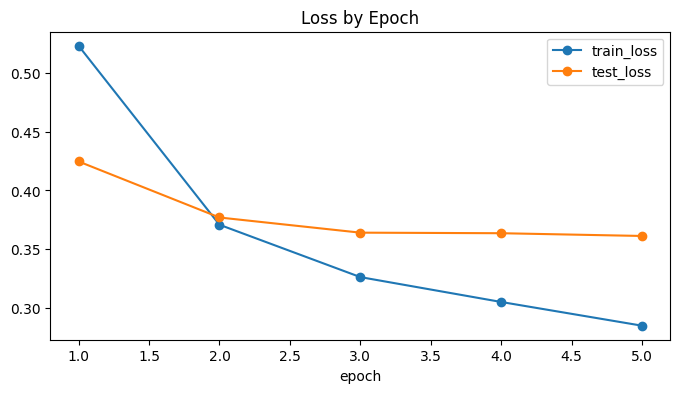

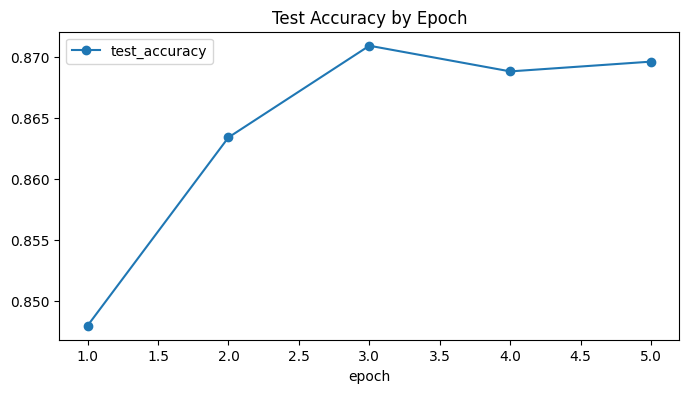

In [40]:
history_df.plot(x="epoch", y=["train_loss", "test_loss"], marker="o", figsize=(8, 4))
plt.title("Loss by Epoch")
plt.show()

history_df.plot(x="epoch", y="test_accuracy", marker="o", figsize=(8, 4))
plt.title("Test Accuracy by Epoch")
plt.show()

In [41]:
model = FashionNet()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

tracked_image, tracked_label = test_ds[0]
tracked_history = []
history = []

for epoch in range(1, 6):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_examples += images.size(0)

    train_loss = total_loss / total_examples

    model.eval()
    total_correct = 0
    total_examples = 0
    total_test_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            logits = model(images)
            loss = loss_fn(logits, labels)

            total_test_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_examples += images.size(0)

        tracked_logits = model(tracked_image.unsqueeze(0))
        tracked_probs = torch.softmax(tracked_logits, dim=1).squeeze().cpu().numpy()
        tracked_pred = tracked_probs.argmax()

    test_loss = total_test_loss / total_examples
    test_accuracy = total_correct / total_examples

    history.append((epoch, train_loss, test_loss, test_accuracy))
    tracked_history.append((epoch, tracked_pred, tracked_probs.copy()))

    print(f"epoch={epoch} train_loss={train_loss:.4f} test_loss={test_loss:.4f} test_accuracy={test_accuracy:.4f}")

epoch=1 train_loss=0.5206 test_loss=0.4135 test_accuracy=0.8512
epoch=2 train_loss=0.3730 test_loss=0.3894 test_accuracy=0.8564
epoch=3 train_loss=0.3348 test_loss=0.3695 test_accuracy=0.8667
epoch=4 train_loss=0.3071 test_loss=0.3602 test_accuracy=0.8733
epoch=5 train_loss=0.2875 test_loss=0.3329 test_accuracy=0.8804


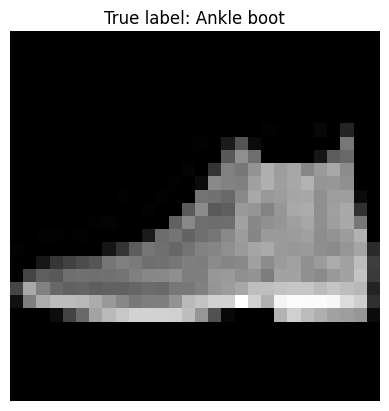

Epoch 1: predicted Ankle boot
  T-shirt/top: 0.000
  Trouser: 0.000
  Pullover: 0.000
  Dress: 0.000
  Coat: 0.000
  Sandal: 0.052
  Shirt: 0.000
  Sneaker: 0.093
  Bag: 0.002
  Ankle boot: 0.853
Epoch 2: predicted Ankle boot
  T-shirt/top: 0.000
  Trouser: 0.000
  Pullover: 0.000
  Dress: 0.000
  Coat: 0.000
  Sandal: 0.090
  Shirt: 0.000
  Sneaker: 0.115
  Bag: 0.001
  Ankle boot: 0.793
Epoch 3: predicted Ankle boot
  T-shirt/top: 0.000
  Trouser: 0.000
  Pullover: 0.000
  Dress: 0.000
  Coat: 0.000
  Sandal: 0.005
  Shirt: 0.000
  Sneaker: 0.034
  Bag: 0.000
  Ankle boot: 0.961
Epoch 4: predicted Ankle boot
  T-shirt/top: 0.000
  Trouser: 0.000
  Pullover: 0.000
  Dress: 0.000
  Coat: 0.000
  Sandal: 0.002
  Shirt: 0.000
  Sneaker: 0.025
  Bag: 0.000
  Ankle boot: 0.973
Epoch 5: predicted Ankle boot
  T-shirt/top: 0.000
  Trouser: 0.000
  Pullover: 0.000
  Dress: 0.000
  Coat: 0.000
  Sandal: 0.007
  Shirt: 0.000
  Sneaker: 0.053
  Bag: 0.000
  Ankle boot: 0.939


In [42]:
plt.imshow(tracked_image.squeeze(), cmap="gray")
plt.title(f"True label: {label_names[tracked_label]}")
plt.axis("off")
plt.show()

for epoch, pred, probs in tracked_history:
    print(f"Epoch {epoch}: predicted {label_names[pred]}")
    for i, p in enumerate(probs):
        print(f"  {label_names[i]}: {p:.3f}")
